In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_excel("Base_de_Leads_limpia.xlsx")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha de Alta  210 non-null    datetime64[ns]
 1   Mes Lead       210 non-null    int64         
 2   ID_Lead        210 non-null    object        
 3   Titulo         210 non-null    object        
 4   Nombre         210 non-null    object        
 5   Producto       210 non-null    object        
 6   Temperatura    210 non-null    object        
 7   Comentario     210 non-null    object        
 8   Asesor         210 non-null    object        
 9   Fuente         210 non-null    object        
 10  Origen         210 non-null    object        
 11  Estatus        210 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 19.8+ KB



Se separan columnas cuantitativas de
cualitativas


In [3]:
columnas_numericas = df.select_dtypes(include="number").columns.tolist()
columnas_fecha = df.select_dtypes(include="datetime").columns.tolist()
columnas_texto = df.select_dtypes(include="object").columns.tolist()

print("Columnas numéricas:", columnas_numericas)
print("Columnas de fecha:", columnas_fecha)
print("Columnas de texto / categóricas:", columnas_texto)


Columnas numéricas: ['Mes Lead']
Columnas de fecha: ['Fecha de Alta']
Columnas de texto / categóricas: ['ID_Lead', 'Titulo', 'Nombre', 'Producto', 'Temperatura', 'Comentario', 'Asesor', 'Fuente', 'Origen', 'Estatus']


In [4]:
df[columnas_numericas].describe()


,Mes Lead
count,210.0
mean,11.0
std,0.0
min,11.0
25%,11.0
50%,11.0
75%,11.0
max,11.0


Aunque las columnas originales no sirven mucho para detectar valores atípicos, lo que sí se puede hacer es calcular tres variables que son los leads capturados por día, para identificar días con cantidades inusuales, luego los leads asignados por asesor, para ver si algún asesor tiene una carga fuera de lo normal y una de longitud del comentario, para detectar comentarios demasiado cortos o largos.



In [5]:
leads_por_dia = df["Fecha de Alta"].dt.date.value_counts().sort_index()
leads_por_asesor = df["Asesor"].value_counts()
longitud_comentario = df["Comentario"].astype(str).str.len()

variables_derivadas = pd.DataFrame({
    "leads_por_dia": leads_por_dia.reset_index(drop=True),
})
print(leads_por_dia.describe())
print()
print(leads_por_asesor.describe())
print()
print(longitud_comentario.describe())


count    24.000000
mean      8.750000
std       6.542503
min       1.000000
25%       3.750000
50%       7.000000
75%      13.750000
max      22.000000
Name: count, dtype: float64

count    11.000000
mean     19.090909
std       7.381796
min       7.000000
25%      15.500000
50%      20.000000
75%      24.000000
max      29.000000
Name: count, dtype: float64

count    210.000000
mean      34.938095
std       16.175502
min        3.000000
25%       24.000000
50%       33.500000
75%       42.750000
max      118.000000
Name: Comentario, dtype: float64


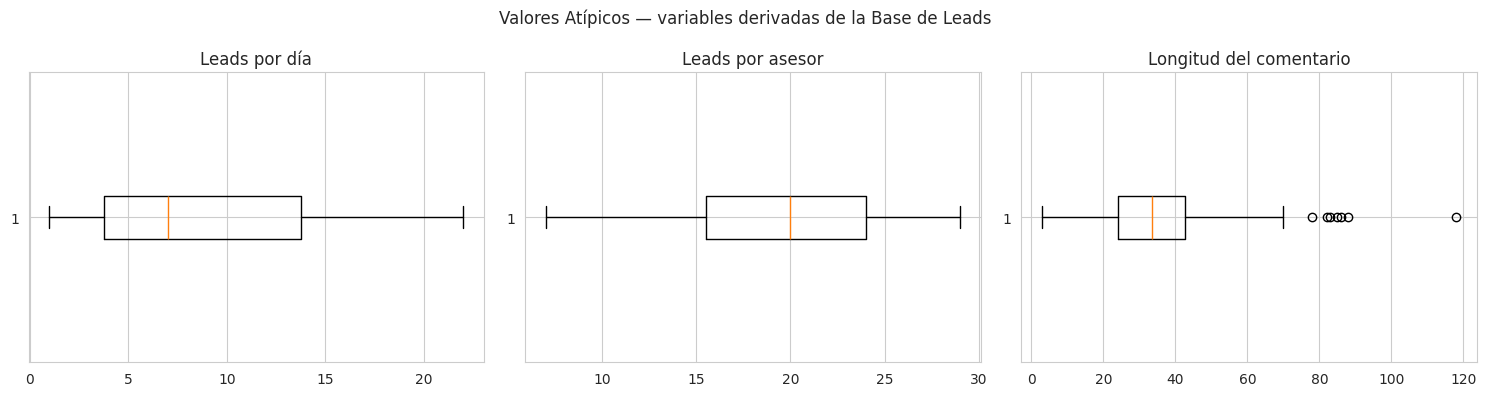

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(leads_por_dia.values, vert=False)
axes[0].set_title("Leads por día")

axes[1].boxplot(leads_por_asesor.values, vert=False)
axes[1].set_title("Leads por asesor")

axes[2].boxplot(longitud_comentario.values, vert=False)
axes[2].set_title("Longitud del comentario")

plt.suptitle("Valores Atípicos — variables derivadas de la Base de Leads")
plt.tight_layout()
plt.show()


Se usa la desviación estándar y se aplica a las tres variables derivadas.


In [7]:
def limites_std(serie, n_sigma=3):
    media, sd = serie.mean(), serie.std()
    return media - n_sigma * sd, media + n_sigma * sd

for nombre, serie in [
    ("Leads por día", leads_por_dia),
    ("Leads por asesor", leads_por_asesor),
    ("Longitud del comentario", longitud_comentario),
]:
    li, ls = limites_std(serie)
    atipicos = serie[(serie < li) | (serie > ls)]
    print(f"--- {nombre} ---")
    print(f"Límite inferior permitido: {li:.2f}  |  Límite superior permitido: {ls:.2f}")
    print(f"Valores atípicos encontrados: {len(atipicos)}")
    if len(atipicos):
        print(atipicos)
    print()


--- Leads por día ---
Límite inferior permitido: -10.88  |  Límite superior permitido: 28.38
Valores atípicos encontrados: 0

--- Leads por asesor ---
Límite inferior permitido: -3.05  |  Límite superior permitido: 41.24
Valores atípicos encontrados: 0

--- Longitud del comentario ---
Límite inferior permitido: -13.59  |  Límite superior permitido: 83.46
Valores atípicos encontrados: 4
14      86
44     118
59      88
121     85
Name: Comentario, dtype: int64



 Método de rango intercuartílico (IQR)

In [8]:
def limites_iqr(serie, factor=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr

resultados_iqr = {}
for nombre, serie in [
    ("Leads por día", leads_por_dia),
    ("Leads por asesor", leads_por_asesor),
    ("Longitud del comentario", longitud_comentario),
]:
    li, ls = limites_iqr(serie)
    atipicos = serie[(serie < li) | (serie > ls)]
    resultados_iqr[nombre] = atipicos
    print(f"--- {nombre} ---")
    print(f"Límite inferior permitido: {li:.2f}  |  Límite superior permitido: {ls:.2f}")
    print(f"Valores atípicos encontrados: {len(atipicos)}")
    if len(atipicos):
        print(atipicos)
    print()


--- Leads por día ---
Límite inferior permitido: -11.25  |  Límite superior permitido: 28.75
Valores atípicos encontrados: 0

--- Leads por asesor ---
Límite inferior permitido: 2.75  |  Límite superior permitido: 36.75
Valores atípicos encontrados: 0

--- Longitud del comentario ---
Límite inferior permitido: -4.12  |  Límite superior permitido: 70.88
Valores atípicos encontrados: 7
14      86
44     118
59      88
88      78
121     85
175     83
192     82
Name: Comentario, dtype: int64



En base al análisis, decidí no reemplazar ni eliminar los valores atípicos, porque no necesariamente representan errores. Por ejemplo, un día con muchos leads puede deberse a una campaña, pero también al atraso en la captura de los asesores, donde registran en un mismo día varios leads que realmente ocurrieron en fechas anteriores (como ellos comentaban). Por eso, estos valores pueden contener información importante del negocio y, en lugar de eliminarlos o reemplazarlos, solo se reportan para su revisión.

In [10]:
dias_atipicos = leads_por_dia[(leads_por_dia < limites_iqr(leads_por_dia)[0]) |
                                  (leads_por_dia > limites_iqr(leads_por_dia)[1])]
asesores_atipicos = leads_por_asesor[(leads_por_asesor < limites_iqr(leads_por_asesor)[0]) |
                                      (leads_por_asesor > limites_iqr(leads_por_asesor)[1])]
comentarios_atipicos = df.loc[
    longitud_comentario > limites_iqr(longitud_comentario)[1], ["Comentario"]
]

print("Días con volumen de leads atípico:")
print(dias_atipicos)
print()
print("Asesores con carga de leads atípica:")
print(asesores_atipicos)
print()
print("Comentarios inusualmente largos:")
comentarios_atipicos


Días con volumen de leads atípico:
Series([], Name: count, dtype: int64)

Asesores con carga de leads atípica:
Series([], Name: count, dtype: int64)

Comentarios inusualmente largos:


,Comentario
14,mandar cotización en arrendamiento con y sin e...
44,SE LE VIO EN ANGELOPOLIS LE AGRADA TRABAJA EN ...
59,envío información en seguimiento revisamos via...
88,se manda catalogo para que conozca mas de nues...
121,quiere dejar a cuenta su Denali está viendo si...
175,paso Angelópolis vio racer se le enviará el ca...
192,se le manda tarjeta de presentación y catálogo...


In [11]:
RUTA_SALIDA = "Base_de_Leads_analizada.xlsx"
df.to_excel(RUTA_SALIDA, index=False)
print(f"Base exportada a: {RUTA_SALIDA}")


Base exportada a: Base_de_Leads_analizada.xlsx


In [12]:
# Si el notebook se ejecuta en Google Colab, esta celda descarga el archivo al equipo.
# En un entorno local/Jupyter normal, el archivo ya quedó guardado en la ruta de arriba.
try:
    from google.colab import files
    files.download(RUTA_SALIDA)
except ImportError:
    print("No estás en Google Colab: el archivo ya está guardado localmente en", RUTA_SALIDA)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>